# Сравнение изображений по матожиданию и стандартному отклонению

Размер изображения: (400, 600)


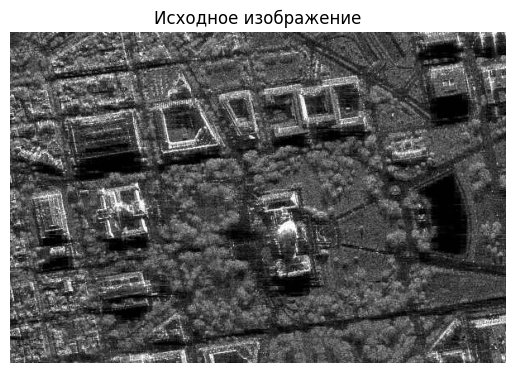

In [28]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd


# Загружаем изображение
image = cv2.imread('sar_1_gray.jpg', 0)
print("Размер изображения:", image.shape)

# Покажем исходное изображение
plt.imshow(image, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

In [29]:
# Функция сравнения двух изображений по матожиданию и стандартному отклонению
def compare_by_moments(img1, img2, t):
    m1, s1 = img1.mean(), img1.std()
    m2, s2 = img2.mean(), img2.std()
    return 1 if (abs(m1 - m2) <= t and abs(s1 - s2) <= t) else 0

In [30]:
# Характеристики исходного изображения
m0 = image.mean()
s0 = image.std()
print(f"Исходное изображение: среднее = {m0:.2f}, ст. отклонение = {s0:.2f}")

Исходное изображение: среднее = 74.94, ст. отклонение = 43.66


# тестирование

In [ ]:
import pandas as pd

# Набор значений гаммы для тестирования (близких к 1)
gammas = [0.95, 0.98, 1.0, 1.02, 1.2]

# Пороги для проверки
thresholds = [1, 3, 5, 7, 10, 15]

# Собираем данные для pandas
data = []
for gamma in gammas:
    img_gamma = np.uint8(np.power(image / 255.0, gamma) * 255)
    row = {
        'Гамма': gamma,
        'Среднее': round(img_gamma.mean(), 1),
        'Ст.откл.': round(img_gamma.std(), 1)
    }
    for t in thresholds:
        row[f't={t}'] = compare_by_moments(image, img_gamma, t)
    data.append(row)

# Создаём DataFrame
df = pd.DataFrame(data)

# Выводим таблицу
print("Сравнение исходного изображения с гамма-корректированными версиями:\n")
print(df)

Сравнение исходного изображения с гамма-корректированными версиями:

   Гамма  Среднее  Ст.откл.  t=1  t=3  t=5  t=7  t=10  t=15
0   0.95     78.4      44.0    0    0    1    1     1     1
1   0.98     75.8      43.7    1    1    1    1     1     1
2   1.00     74.9      43.7    1    1    1    1     1     1
3   1.02     73.1      43.6    0    1    1    1     1     1
4   1.20     60.6      42.0    0    0    0    0     0     1


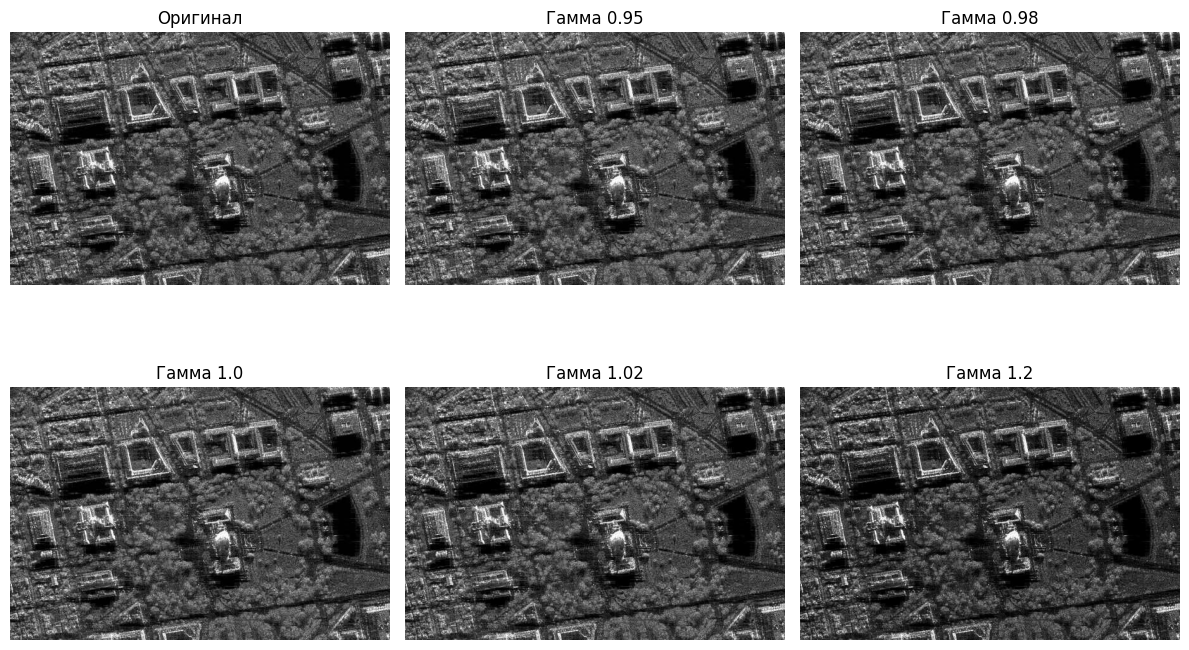

In [32]:
# Визуализация: оригинал и модификации
plt.figure(figsize=(12, 8))

# Оригинал
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Оригинал')
plt.axis('off')

# Гамма-версии
for i, gamma in enumerate(gammas, start=2):
    img_gamma = np.uint8(np.power(image / 255.0, gamma) * 255)
    plt.subplot(2, 3, i)
    plt.imshow(img_gamma, cmap='gray')
    plt.title(f'Гамма {gamma}')
    plt.axis('off')

plt.tight_layout()
plt.show()